## Ridge Regression

In [1]:
from sklearn.datasets import load_diabetes
import pandas as pd

data = load_diabetes(as_frame=True)

df = data.frame

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [2]:
df.shape

(442, 11)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [4]:
x = df[['age','sex','bmi','bp','s1','s2','s3','s5','s4','s6']]
y = df['target']

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Split the dataset for traning and testing
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size = 0.1, random_state = 42)

In [6]:
# Feature Scaling for Ridge
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [7]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((397, 10), (45, 10), (397,), (45,))

In [8]:
from sklearn.linear_model import Ridge

model = Ridge(alpha= 0.2)
model.fit(x_train,y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",0.2
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [9]:
model.intercept_

np.float64(151.92221515930163)

In [10]:
model.coef_

array([  27.91845323, -195.52299565,  442.63094044,  287.46179648,
        -62.53380412,  -82.17902525, -193.7649086 ,  368.51131345,
        134.37539256,  102.90929584])

In [11]:
y_pred = model.predict(x_test)
y_pred

array([148.77094893, 172.79052449, 146.05341055, 279.15743266,
       129.03775349, 107.356891  , 241.34427356, 191.69974361,
        97.16072193, 119.76652932, 104.21304602, 155.79260491,
        72.922168  , 204.64354261, 109.72274488, 134.1717107 ,
       217.32208958, 236.56602344, 184.8856543 , 206.58037053,
       198.1026478 ,  97.63661372,  83.78949754, 184.97678606,
       153.60037589, 161.13755381, 181.6707651 , 172.46577379,
        61.60991514, 121.54103454, 176.20746138, 101.31754857,
       135.92824347, 179.43868033, 172.87284906, 187.83373689,
       130.19375421, 128.55767935, 154.23474371,  70.16447343,
        88.81208816, 113.81555116, 156.42446666, 154.3150867 ,
       175.01358942])

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 42.39013191853096
MSE : 2797.5275547359315
RMSE: 52.89165864988478
R²  : 0.5426547933031132


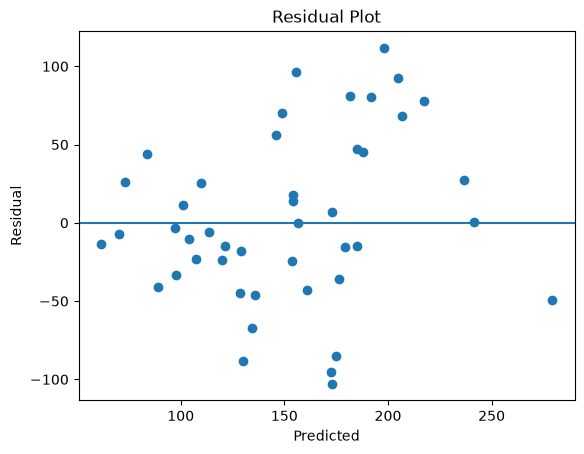

In [13]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

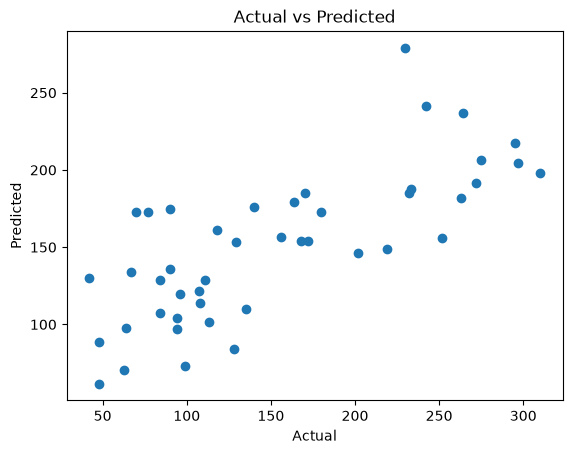

In [14]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

## practice questions

In [15]:
from sklearn.datasets import make_regression
import numpy as np

x, y = make_regression(
    n_samples=200,
    n_features=5,
    n_informative=3,
    noise=30,
    random_state=42
)

# Create highly correlated features
x[:, 4] = x[:, 0] * 0.95 + np.random.normal(0, 0.1, 200)

In [18]:
x.shape

(200, 5)

In [19]:
print(np.corrcoef(x[:, 0], x[:, 4])[0, 1])

0.9944480637377395


In [20]:
# first lets split the dataset

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x, y, test_size= 0.2, random_state= 42)


In [22]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(x_train,y_train)

y_pred = lr.predict(x_test)

print("Linear Coefficients: ")
print(lr.coef_)


Linear Coefficients: 
[ 34.48480799  12.45284802  66.95778777  20.6643887  -37.00533357]


In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

lr = LinearRegression()
lr.fit(x_train_scaled, y_train)

ridge = Ridge(alpha=1)
ridge.fit(x_train_scaled, y_train)

print("Linear coefficients:")
print(lr.coef_)

print("\nRidge coefficients:")
print(ridge.coef_)

Linear coefficients:
[ 35.84569523  12.16135142  64.55602608  19.66690651 -37.01112583]

Ridge coefficients:
[ 16.01266632  11.97304592  64.3252193   19.44337698 -17.12703375]


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predictions
y_pred_lr = lr.predict(x_test_scaled)
y_pred_ridge = ridge.predict(x_test_scaled)

# Evaluation
for name, pred in [
    ("Linear Regression", y_pred_lr),
    ("Ridge", y_pred_ridge)
]:
    print("\n", name)
    print("MAE :", mean_absolute_error(y_test, pred))
    print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)
    print("R²  :", r2_score(y_test, pred))


 Linear Regression
MAE : 22.82490612001519
RMSE: 26.885562976482984
R²  : 0.8227341894215905

 Ridge
MAE : 22.891293281085144
RMSE: 26.85449692849619
R²  : 0.8231436111298794


In [29]:
for alpha in [0, 0.01, 0.1, 1, 10, 100, 1000]:
    model = Ridge(alpha=alpha)
    model.fit(x_train_scaled, y_train)
    
    pred = model.predict(x_test_scaled)
    
    print(
        f"alpha={alpha:<6} "
        f"RMSE={mean_squared_error(y_test, pred)**0.5:.3f} "
        f"R²={r2_score(y_test, pred):.4f}"
    )

alpha=0      RMSE=26.886 R²=0.8227
alpha=0.01   RMSE=26.885 R²=0.8227
alpha=0.1    RMSE=26.882 R²=0.8228
alpha=1      RMSE=26.854 R²=0.8231
alpha=10     RMSE=25.738 R²=0.8375
alpha=100    RMSE=28.890 R²=0.7953
alpha=1000   RMSE=55.120 R²=0.2549


# Ridge Regression — Complete Notes

## 1. What is Ridge Regression?

**Ridge Regression** is a regularized version of Linear Regression.

It is mainly useful when:

* Features are highly correlated (**multicollinearity**).
* Linear Regression coefficients become unstable.
* We want to reduce overfitting / model variance.
* We want to constrain very large coefficients.

Ridge still uses the same basic linear model:

$$
\hat y = b_0 + b_1x_1+b_2x_2+\cdots+b_px_p
$$

The major difference is that Ridge adds a **penalty for large coefficients**.

---

# 2. Why Ridge?

Consider two highly correlated features:

```text
Feature 1 ─────────┐
                   ├── contain almost the same information
Feature 2 ─────────┘
```

Ordinary Linear Regression may struggle to decide how much importance to assign to each feature.

This can result in:

* Large coefficients
* Opposite-signed coefficients
* Unstable coefficients
* Coefficients changing significantly with small changes in training data

### Example from our experiment

We deliberately created two features with approximately:

```text
Correlation ≈ 0.994
```

Linear Regression produced:

```text
Feature 1 → +35.85
Feature 5 → -37.01
```

Ridge produced:

```text
Feature 1 → +16.01
Feature 5 → -17.13
```

Ridge **shrunk the coefficients**.

---

# 3. Ridge Regression Equation

### Ordinary Linear Regression

OLS minimizes:

$$
\sum_{i=1}^{n}(y_i-\hat y_i)^2
$$

### Ridge

Ridge minimizes:

$$
\boxed{
\sum_{i=1}^{n}(y_i-\hat y_i)^2
+
\alpha\sum_{j=1}^{p}w_j^2
}
$$

The second part is the **L2 regularization penalty**:

$$
\alpha\sum w_j^2
$$

Where:

* \(w_j\) = model coefficients
* \(\alpha\) = regularization strength
* \(w_j^2\) = squared coefficient

### Core idea

> Ridge tells the model: **fit the data well, but avoid unnecessarily large coefficients.**

---

# 4. What is L2 Regularization?

Ridge uses **L2 regularization** because the coefficients are squared:

$$
w_1^2+w_2^2+\cdots+w_p^2
$$

Large coefficients become expensive because squaring makes them grow quickly.

For example:

$$
2^2=4
$$

but

$$
10^2=100
$$

So Ridge strongly discourages large coefficient values.

---

# 5. Alpha

`alpha` controls the strength of regularization.

```python
Ridge(alpha=1)
```

### Small alpha

```text
alpha → small
↓
weak penalty
↓
less coefficient shrinkage
↓
behaves more like Linear Regression
```

### Large alpha

```text
alpha → large
↓
strong penalty
↓
more coefficient shrinkage
↓
higher bias
↓
lower variance
```

If alpha becomes **too large**, the model can underfit.

---

# 6. Alpha = 0

Conceptually:

$$
\alpha=0
$$

means:

$$
\text{Ridge} \approx \text{Ordinary Linear Regression}
$$

Our experiment showed:

```text
alpha=0
RMSE=26.886
R²=0.8227
```

which was essentially the same as Linear Regression.

---

# 7. Coefficient Shrinkage

One of the most important Ridge concepts.

Ridge pushes coefficients toward zero:

```text
Linear Regression:

+35.85
-37.01

       ↓ Ridge

+16.01
-17.13
```

### Important distinction

Ridge **does not directly penalize multicollinearity**.

It penalizes:

$$
\boxed{\text{large coefficient magnitudes}}
$$

This helps make the model more stable when multicollinearity exists.

### Ridge vs Lasso

| Method | Penalty     | Typical behavior     |   |                                 |
| ------ | ----------- | -------------------- | - | ------------------------------- |
| Ridge  | L2: \(w^2\) | Shrinks coefficients |   |                                 |
| Lasso  | L1: (       | w                    | ) | Can make coefficients exactly 0 |

Lasso will be covered later.

---

# 8. Feature Scaling

Feature scaling is especially important for Ridge.

Suppose:

```text
Feature A → 0–1
Feature B → 0–100,000
```

Because Ridge penalizes coefficient magnitude, different feature scales can cause the regularization to affect features unfairly.

A common solution is **Standardization**:

$$
z=\frac{x-\mu}{\sigma}
$$

This gives features approximately:

```text
mean = 0
standard deviation = 1
```

### Correct workflow

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
```

### Why not `fit_transform()` on test data?

`fit()` learns the scaling parameters:

```text
mean
standard deviation
```

We learn them **only from training data**.

Then:

```python
scaler.transform(x_test)
```

uses those already-learned training parameters.

Doing:

```python
scaler.fit_transform(x_test)
```

would allow information from the test set to influence preprocessing.

That's a form of **data leakage**.

---

# 9. Ridge + Multicollinearity

### Multicollinearity

Multicollinearity occurs when predictor variables are highly correlated.

Example:

```text
Years of Experience
        ↕
Age
```

They may contain overlapping information.

### Problem for Linear Regression

Coefficients can become:

* Unstable
* Difficult to interpret
* Sensitive to changes in training data

### Ridge

Ridge constrains coefficient magnitudes:

$$
\alpha\sum w_j^2
$$

This generally makes the coefficient estimates more stable.

---

# 10. Bias-Variance Tradeoff

Regularization creates a tradeoff.

As alpha increases:

$$
\boxed{\text{Bias} \uparrow}
$$

$$
\boxed{\text{Variance} \downarrow}
$$

Meaning:

```text
Low alpha
   ↓
less restriction
   ↓
lower bias
higher variance
```

versus:

```text
High alpha
   ↓
strong restriction
   ↓
higher bias
lower variance
```

Too much regularization:

```text
Bias becomes too high
        ↓
Underfitting
        ↓
Poor test performance
```

---

# 11. Our Alpha Experiment

We tested:

```text
alpha=0      RMSE=26.886   R²=0.8227
alpha=0.01   RMSE=26.885   R²=0.8227
alpha=0.1    RMSE=26.882   R²=0.8228
alpha=1      RMSE=26.854   R²=0.8231
alpha=10     RMSE=25.738   R²=0.8375  ← best here
alpha=100    RMSE=28.890   R²=0.7953
alpha=1000   RMSE=55.120   R²=0.2549
```

This demonstrates the typical pattern:

```text
Too little regularization
        ↓
     improve
        ↓
   optimal region
        ↓
Too much regularization
        ↓
    underfitting
```

For **this particular train/test split and these tested values**, `alpha=10` performed best.

⚠️ Don't conclude that `alpha=10` is universally best.

In real ML, alpha should be selected using **cross-validation** rather than relying on one test split.

---

# 12. Evaluation Metrics

Ridge uses the same regression metrics as Linear Regression.

### MAE

$$
MAE=\frac{1}{n}\sum|y-\hat y|
$$

Average absolute prediction error.

Lower is better.

---

### MSE

$$
MSE=\frac{1}{n}\sum(y-\hat y)^2
$$

Penalizes large errors more heavily.

Lower is better.

---

### RMSE

$$
RMSE=\sqrt{MSE}
$$

Same units as the target.

Lower is better.

---

### R²

$$
R^2=1-\frac{SS_{res}}{SS_{tot}}
$$

Higher is generally better.

It measures performance relative to predicting the mean target.

---

# 13. Comparing Linear Regression and Ridge

Our experiment:

```text
Linear Regression
MAE  = 22.825
RMSE = 26.886
R²   = 0.8227

Ridge
MAE  = 22.891
RMSE = 26.854
R²   = 0.8231
```

So:

* Linear had slightly better MAE.
* Ridge had slightly better RMSE.
* Ridge had slightly better R².
* Differences were small.

Therefore:

> Ridge is **not automatically better** than Linear Regression.

We evaluate both on unseen data and choose based on the problem and validation results.

---

# 14. Basic Ridge Implementation

```python
from sklearn.linear_model import Ridge

model = Ridge(alpha=1)

model.fit(x_train_scaled, y_train)

y_pred = model.predict(x_test_scaled)
```

Evaluation:

```python
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)
```

---

# 15. Proper Ridge Workflow

Conceptually:

```text
Raw Dataset
     ↓
Train/Test Split
     ↓
Fit scaler on training data
     ↓
Transform train + test
     ↓
Train Ridge
     ↓
Predict
     ↓
Evaluate
     ↓
Tune alpha using Cross-Validation
```

In production, a `Pipeline` is usually cleaner:

```python
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1))
])

model.fit(x_train, y_train)

y_pred = model.predict(x_test)
```

This becomes especially useful when we start doing **cross-validation and hyperparameter tuning**.

---

# 16. Common Mistakes

### ❌ Mistake 1: Thinking Ridge removes correlated features

Ridge generally **doesn't remove features**.

It shrinks their coefficients.

---

### ❌ Mistake 2: Saying Ridge penalizes multicollinearity

More precise:

> Ridge penalizes large coefficient magnitudes, which can help stabilize models affected by multicollinearity.

---

### ❌ Mistake 3: Larger alpha is always better

No.

```text
alpha too small → insufficient regularization
alpha appropriate → good generalization
alpha too large → underfitting
```

---

### ❌ Mistake 4: Choosing alpha using the test set

Don't repeatedly optimize alpha against the test set.

Use:

```text
Training data
     ↓
Cross-validation
     ↓
Choose alpha
     ↓
Final evaluation on test set
```

---

### ❌ Mistake 5: Scaling test data separately

Wrong:

```python
x_test_scaled = scaler.fit_transform(x_test)
```

Correct:

```python
x_test_scaled = scaler.transform(x_test)
```

---

### ❌ Mistake 6: Comparing coefficients from differently scaled models

If one model uses raw features and another uses standardized features, their coefficient magnitudes aren't directly comparable.

For coefficient comparison, use the **same feature representation/scaling**.

---

# 17. Ridge vs Linear Regression

|                              | Linear Regression | Ridge                     |
| ---------------------------- | ----------------- | ------------------------- |
| Regularization               | ❌                 | ✅                         |
| L2 penalty                   | ❌                 | ✅                         |
| Coefficient shrinkage        | ❌                 | ✅                         |
| Helps with multicollinearity | Limited           | ✅                         |
| Can reduce variance          | Limited           | ✅                         |
| Can underfit if excessive    | —                 | ✅                         |
| Needs scaling?               | Usually not       | **Recommended/important** |
| Alpha                        | —                 | Regularization strength   |

---

# 18. Interview Answers 🎤

### What is Ridge Regression?

> Ridge Regression is Linear Regression with L2 regularization. It adds a penalty proportional to the squared coefficient values, shrinking coefficients and helping reduce variance and stabilize models, particularly when multicollinearity is present.

### Why use Ridge?

> Ridge is useful when predictors are highly correlated or when ordinary Linear Regression has unstable coefficients. The L2 penalty constrains coefficient magnitudes and can improve generalization.

### What happens when alpha increases?

> Increasing alpha strengthens regularization, causing greater coefficient shrinkage. This generally increases bias and decreases variance; if alpha becomes too large, the model can underfit.

### Why scale features for Ridge?

> Ridge penalizes coefficient magnitudes, so features with different scales can be regularized unfairly. Standardization puts features on comparable scales before applying the penalty.

---

# 19. The Mental Model 🧠

Remember Ridge as:

```text
Linear Regression
       +
"Don't make coefficients unnecessarily large"
       ↓
     Ridge
       ↓
L2 penalty
       ↓
Coefficient shrinkage
       ↓
Lower variance
       ↓
Potentially better generalization
```

And the most important relationship:

```text
Multicollinearity
       ↓
Unstable coefficients
       ↓
Ridge
       ↓
L2 penalty
       ↓
Coefficient shrinkage
       ↓
More stable model
```

### ⭐ What you actually need to remember

If you remember only these **7 things**, you're good:

1. **Ridge = Linear Regression + L2 regularization**
2. L2 penalty = \(\alpha\sum w^2\)
3. Larger `alpha` → stronger coefficient shrinkage
4. Ridge usually **shrinks** coefficients rather than making them zero
5. Ridge is particularly useful with **multicollinearity**
6. **Scale features** before Ridge
7. Choose `alpha` based on **validation/CV performance**, not blindly.
